# NLP Project — Medical Chatbot
## Step 2: SentencePiece Tokenizer Training
**Input:** `data/train.txt`  
**Output:** `tokenizer/medical_bpe.model` and `tokenizer/medical_bpe.vocab`

### Cell 1 — Install SentencePiece

### Cell 2 — Train Tokenizer on train.txt only

In [1]:
import sentencepiece as spm
import os

# Create tokenizer directory
os.makedirs('../tokenizer', exist_ok=True)

# Train BPE tokenizer
# NOTE: We train on train.txt ONLY — never on val or test
spm.SentencePieceTrainer.train(
    input='../data/train.txt',
    model_prefix='../tokenizer/medical_bpe',
    model_type='bpe',
    vocab_size=8000,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
    user_defined_symbols=['<eos>', '<patient>', '<doctor>'],  # ← add <eos> here
    character_coverage=1.0,
    input_sentence_size=100000,
    shuffle_input_sentence=True,
)


print("Tokenizer trained successfully ✓")
print("Saved:")
print("  tokenizer/medical_bpe.model")
print("  tokenizer/medical_bpe.vocab")

Tokenizer trained successfully ✓
Saved:
  tokenizer/medical_bpe.model
  tokenizer/medical_bpe.vocab


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ../data/train.txt
  input_format: 
  model_prefix: ../tokenizer/medical_bpe
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 100000
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <eos>
  user_defined_symbols: <patient>
  user_defined_symbols: <doctor>
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>


### Cell 3 — Load and Verify Tokenizer

In [2]:
# Load trained tokenizer
sp = spm.SentencePieceProcessor()
sp.load('../tokenizer/medical_bpe.model')

print(f"Vocabulary size : {sp.get_piece_size()}")
print(f"<pad>  token id : {sp.piece_to_id('<pad>')}")
print(f"<unk>  token id : {sp.piece_to_id('<unk>')}")
print(f"<eos>  token id : {sp.piece_to_id('<eos>')}")
print(f"<patient> id    : {sp.piece_to_id('<patient>')}")
print(f"<doctor>  id    : {sp.piece_to_id('<doctor>')}")

Vocabulary size : 8000
<pad>  token id : 0
<unk>  token id : 1
<eos>  token id : 4
<patient> id    : 5
<doctor>  id    : 6


### Cell 4 — Test Encode and Decode

In [3]:
# Test with a sample sequence
sample = "<patient> I have severe pain in my lower abdomen and fever since 2 days. <doctor> This could be appendicitis or urinary tract infection. Please consult a doctor immediately. <eos>"

# Encode — text to token ids
encoded = sp.encode(sample, out_type=int)
print(f"Original text  : {sample}")
print(f"\nEncoded ids    : {encoded}")
print(f"Token count    : {len(encoded)}")

# Decode — token ids back to text
decoded = sp.decode(encoded)
print(f"\nDecoded text   : {decoded}")
print(f"\nMatch original : {sample.strip() == decoded.strip()}")

Original text  : <patient> I have severe pain in my lower abdomen and fever since 2 days. <doctor> This could be appendicitis or urinary tract infection. Please consult a doctor immediately. <eos>

Encoded ids    : [7831, 5, 36, 81, 520, 83, 38, 79, 424, 625, 32, 419, 586, 205, 310, 7850, 7831, 6, 2352, 84, 316, 56, 3264, 100, 2266, 2019, 350, 7850, 710, 383, 7, 263, 2075, 7850, 7831, 4]
Token count    : 36

Decoded text   : <patient> I have severe pain in my lower abdomen and fever since 2 days. <doctor> This could be appendicitis or urinary tract infection. Please consult a doctor immediately. <eos>

Match original : True


### Cell 5 — Check Sequence Length Distribution After Tokenization
This is important — words become subword tokens, so token count > word count

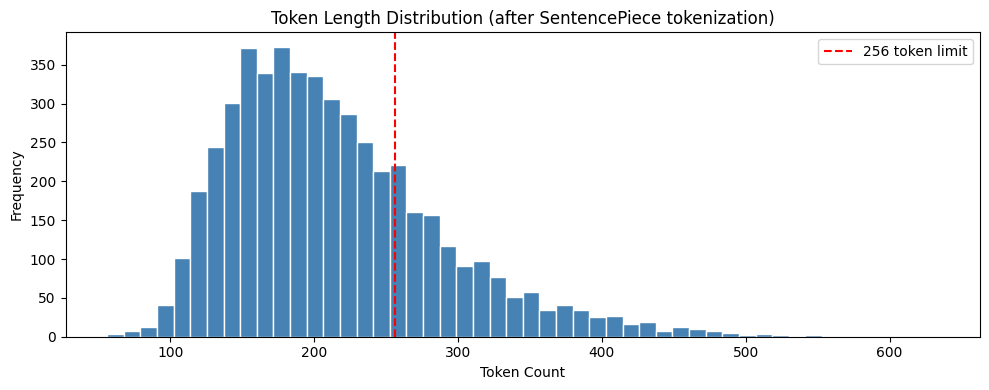

Avg token length : 214.3
Max token length : 634
% within 256     : 75.7%
% within 512     : 99.8%


In [4]:
import matplotlib.pyplot as plt

# Read train sequences
with open('../data/train.txt', 'r', encoding='utf-8') as f:
    train_sequences = [line.strip() for line in f if line.strip()]

# Tokenize all and measure lengths (sample 5000 for speed)
import random
random.seed(42)
sample_seqs = random.sample(train_sequences, min(5000, len(train_sequences)))
token_lengths = [len(sp.encode(seq, out_type=int)) for seq in sample_seqs]

# Plot
plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=256, color='red', linestyle='--', label='256 token limit')
plt.title('Token Length Distribution (after SentencePiece tokenization)')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('../data/token_length_distribution.png', dpi=150)
plt.show()

import numpy as np
print(f"Avg token length : {np.mean(token_lengths):.1f}")
print(f"Max token length : {max(token_lengths)}")
print(f"% within 256     : {(np.array(token_lengths) <= 256).mean()*100:.1f}%")
print(f"% within 512     : {(np.array(token_lengths) <= 512).mean()*100:.1f}%")

### Cell 6 — Confirm Final Sequence Length Decision

In [5]:
# Based on the plot above:
# - If 85%+ sequences fit in 256 tokens → keep MAX_SEQ_LEN = 256
# - If too many are cut → increase to 320 or 384

# We will finalize this number and use it in Step 3 onwards
MAX_SEQ_LEN = 512   # ← update this if needed after seeing Cell 5 output

print(f"Final MAX_SEQ_LEN = {MAX_SEQ_LEN}")
print("This will be used for padding in Step 3 onwards")

# Save tokenizer config for later steps
import json
MAX_SEQ_LEN = 512   # ← updated from 320

config = {
    'model_path'   : '../tokenizer/medical_bpe.model',
    'vocab_size'   : sp.get_piece_size(),
    'max_seq_len'  : 512,       # ← updated
    'batch_size'   : 64,        # ← added
    'd_model'      : 256,       # embedding dim
    'n_heads'      : 4,         # attention heads
    'n_layers'     : 6,         # decoder layers  ← updated
    'ffn_dim'      : 1024,      # feed forward dim
    'pad_id'       : sp.piece_to_id('<pad>'),
    'unk_id'       : sp.piece_to_id('<unk>'),
    'eos_id'       : sp.piece_to_id('<eos>'),
    'patient_id'   : sp.piece_to_id('<patient>'),
    'doctor_id'    : sp.piece_to_id('<doctor>'),
}

with open('../tokenizer/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("\nSaved tokenizer config:")
print(json.dumps(config, indent=2))

Final MAX_SEQ_LEN = 512
This will be used for padding in Step 3 onwards

Saved tokenizer config:
{
  "model_path": "../tokenizer/medical_bpe.model",
  "vocab_size": 8000,
  "max_seq_len": 512,
  "batch_size": 64,
  "d_model": 256,
  "n_heads": 4,
  "n_layers": 6,
  "ffn_dim": 1024,
  "pad_id": 0,
  "unk_id": 1,
  "eos_id": 4,
  "patient_id": 5,
  "doctor_id": 6
}


In [6]:
import random

# Load actual training sequences
with open('../data/train.txt', 'r', encoding='utf-8') as f:
    sequences = [line.strip() for line in f if line.strip()]

# Pick 10 random samples
random.seed(44)
samples = random.sample(sequences, 10)

for i, original in enumerate(samples):
    encoded = sp.encode(original, out_type=int)
    decoded = sp.decode(encoded)
    
    match = original.strip() == decoded.strip()
    
    print(f"{'='*70}")
    print(f"SAMPLE {i+1}")
    print(f"\nORIGINAL : {original[:200]}...")
    print(f"\nENCODED  : {encoded[:20]}... ({len(encoded)} tokens)")
    print(f"\nDECODED  : {decoded[:200]}...")
    print(f"\nMATCH    : {'✅ YES' if match else '❌ NO'}")
    print()

# Summary
all_encoded = [sp.encode(seq, out_type=int) for seq in samples]
all_decoded = [sp.decode(enc) for enc in all_encoded]
matches = sum(o.strip() == d.strip() for o, d in zip(samples, all_decoded))
print(f"{'='*70}")
print(f"SUMMARY: {matches}/10 sequences encode→decode perfectly")

SAMPLE 1

ORIGINAL : <patient> What can cause abdominal pain upon cougng after a gallbladder removal surgery? I had my gallbladder removed 6 days ago I haven t had bad pains but I am hurting a little in my abdomen area wh...

ENCODED  : [7831, 5, 204, 88, 340, 709, 83, 2489, 2000, 249, 7, 4404, 2136, 518, 7860, 36, 175, 79, 4404, 1176]... (180 tokens)

DECODED  : <patient> What can cause abdominal pain upon cougng after a gallbladder removal surgery? I had my gallbladder removed 6 days ago I haven t had bad pains but I am hurting a little in my abdomen area wh...

MATCH    : ✅ YES

SAMPLE 2

ORIGINAL : <patient> Cancer in the pancreas, liver and in right lung My dad is the hospital now the doctors said he has 2 months to live. Tsaid he is 90 percent of cancer what does all ts mean is he going to die...

ENCODED  : [7831, 5, 3754, 38, 27, 4427, 7856, 1295, 32, 38, 348, 1394, 323, 3726, 51, 27, 1119, 295, 27, 1341]... (100 tokens)

DECODED  : <patient> Cancer in the pancreas, liver and i